This notebook tests whether Molmo is able to classify states of objects (e.g.: drawer [open, closed]) by mapping them to an alphabet (e.g.: A = open, B = closed). These letters are then used to construct trivia-like question prompts.

It also checks whether the classification can be done by restricting the model to a single letter as output only.

1. Loading the model

In [1]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_NAME = "allenai/Molmo2-4B"
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    dtype=torch.float32,
    device_map="auto",
)
model.eval()

I0000 00:00:1779883982.710358 1200344 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779883983.511999 1200344 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779883984.863121 1200344 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=T

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Molmo2ForConditionalGeneration(
  (model): Molmo2Model(
    (transformer): Molmo2TextModel(
      (wte): Molmo2Embedding()
      (emb_drop): Dropout(p=0.0, inplace=False)
      (blocks): ModuleList(
        (0-35): 36 x Molmo2DecoderLayer(
          (self_attn): Molmo2Attention(
            (att_proj): Linear(in_features=2560, out_features=6144, bias=False)
            (k_norm): Molmo2RMSNorm((128,), eps=1e-06)
            (q_norm): Molmo2RMSNorm((128,), eps=1e-06)
            (attn_out): Linear(in_features=4096, out_features=2560, bias=False)
          )
          (attn_norm): Molmo2RMSNorm((2560,), eps=1e-06)
          (dropout): Dropout(p=0.0, inplace=False)
          (mlp): LanguageModelMLP(
            (ff_proj): Linear(in_features=2560, out_features=19456, bias=False)
            (ff_out): Linear(in_features=9728, out_features=2560, bias=False)
            (act): SiLUActivation()
          )
          (ff_norm): Molmo2RMSNorm((2560,), eps=1e-06)
        )
      )
      (ln_f): Mo

2. Loading data for testing

In [2]:
from heca.helper import molmo
images, prompts, ground_truths, task_names, letters_per_task = molmo.get_data()

3. Making sure that the Model only predicts single Alphabet tokens

In [3]:
alphabet_tokens = []
for letter in molmo.ALPHABET:
    token_ids = processor.tokenizer.encode(letter, add_special_tokens=False)
    assert len(token_ids) == 1, f"Letter {letter} is not single-token for tokenizer"
    alphabet_tokens.append(token_ids[0])

# Per-sample constrained decoding: only valid letters for that sample's task
cache_allowed_ids = {}
for entity, letters in letters_per_task.items():
    cache_allowed_ids[entity] = alphabet_tokens[: len(letters)]


def prefix_allowed_tokens_fn(batch_id, input_ids):
    return alphabet_tokens

def postprocess_prediction(pred, letters: set[str]) -> str | None:
    post = pred.strip().upper()
    if post in letters:
        return post
    else:
        return None
    

4. Preproccessing the raw promots into molmo format

In [4]:
chat_texts = []
for prompt in prompts:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    chat_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    chat_texts.append(chat_text)

5. Molmo Loop (Batched into blocks of 10 cause of hardware constraints)

In [5]:

predicted_letters = []

batch_size = 10
batch_indexes = list(range(0, len(images), batch_size))

for i in batch_indexes:
    img_batch = images[i : i + batch_size]
    chat_batch = chat_texts[i : i + batch_size]
    task_batch = task_names[i : i + batch_size]
    inputs = processor(
        images=img_batch,
        text=chat_batch,
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    # Molmo2 + torch 2.5 workaround: avoid token_type_ids path that requires torch>=2.6.
    # Its no problem to ignore since Molmo2 doesn't use token_type_ids.
    # TODO: try updating torch version again
    inputs.pop("token_type_ids", None)


    with torch.inference_mode():
        outputs = model.generate(  # type: ignore
            **inputs,
            max_new_tokens=1,
            do_sample=False,
            prefix_allowed_tokens_fn=prefix_allowed_tokens_fn,
        )

    input_lengths = inputs["attention_mask"].sum(dim=1)
    for i in range(len(img_batch)):
        gen_tokens = outputs[i, input_lengths[i] :]
        pred = processor.tokenizer.decode(gen_tokens, skip_special_tokens=True)
        post = postprocess_prediction(pred, letters_per_task[task_batch[i]])
        predicted_letters.append(post)

6. Plotting results

In [6]:
molmo.plot_predictions(predicted_letters, ground_truths, task_names)

TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=left       PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LETTER=A 
TASK=slider     GT=right      PRED=left       LE

7. Sanity Checks

Visual tensor key: pixel_values
Visual tensor shape: (6, 729, 588)
Tensor dtype: torch.float32
Tensor min: -1.0
Tensor max: 1.0


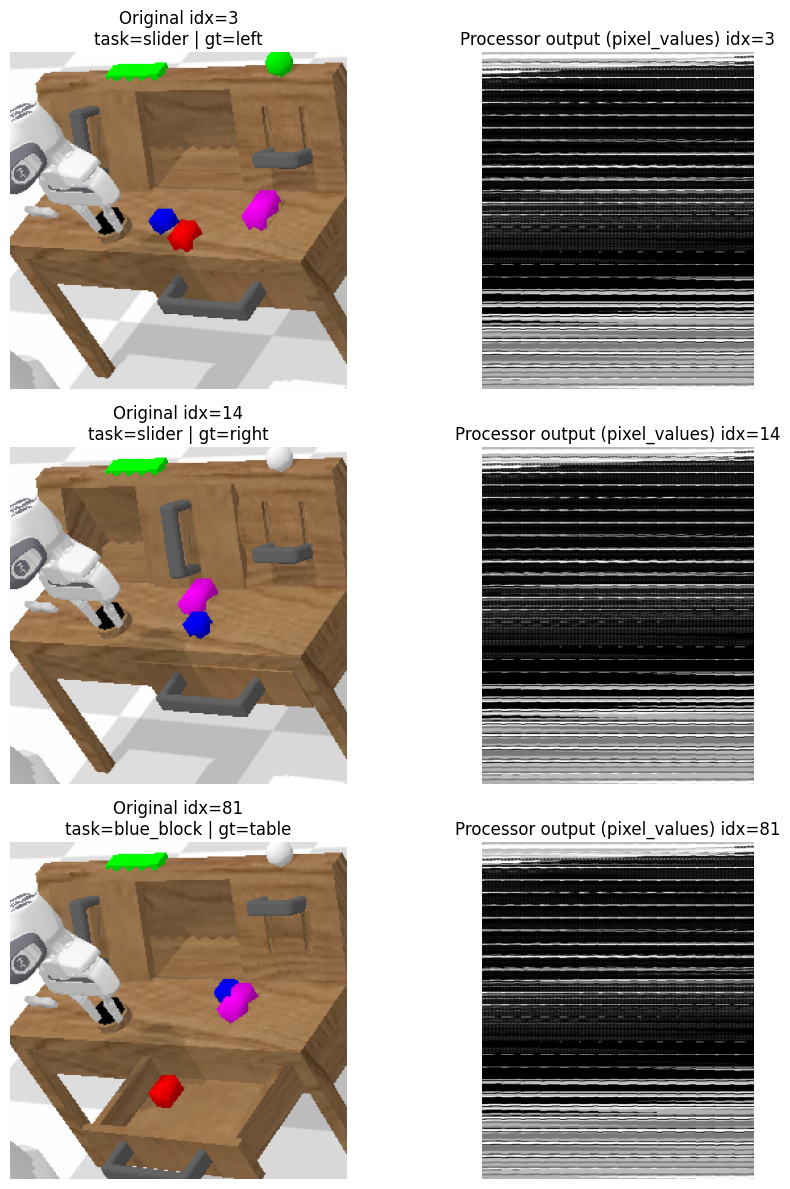

----------------------------------------------------------------------------------------------------
idx=3
task=slider
ground_truth=left

<|image|><|im_start|>user
Is the horizontal slider door, with a grey handle, in the back of the table:
A: moved to the left
B: moved to the right
Answer with exactly one of the letters {'A', 'B'} corresponding to the correct answer.<|im_end|>
<|im_start|>assistant


----------------------------------------------------------------------------------------------------
idx=14
task=slider
ground_truth=right

<|image|><|im_start|>user
Is the horizontal slider door, with a grey handle, in the back of the table:
A: moved to the left
B: moved to the right
Answer with exactly one of the letters {'A', 'B'} corresponding to the correct answer.<|im_end|>
<|im_start|>assistant


----------------------------------------------------------------------------------------------------
idx=81
task=blue_block
ground_truth=table

<|image|><|im_start|>user
Is the blue block:

In [7]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Assumes these already exist in memory from your pipeline:
# model, processor, images, chat_texts, task_names, ground_truths, cache_allowed_ids


def get_visual_tensor(batch):
    for key in ["pixel_values", "images", "image_values", "vision_x"]:
        if key in batch and torch.is_tensor(batch[key]):
            return key, batch[key]

    for key, value in batch.items():
        if torch.is_tensor(value) and value.ndim >= 4:
            return key, value

    raise KeyError(f"No visual tensor found. Keys: {list(batch.keys())}")


def to_display_img(x, processor=None):
    x = x.detach().cpu().float()

    # Handle HW grayscale
    if x.ndim == 2:
        x = x.unsqueeze(0)

    # Ensure CHW
    if x.ndim == 3 and x.shape[0] in [1, 3]:
        pass
    elif x.ndim == 3 and x.shape[-1] in [1, 3]:
        x = x.permute(2, 0, 1)
    else:
        raise ValueError(f"Unexpected image tensor shape: {tuple(x.shape)}")

    # Proper unnormalization if processor stats exist
    try:
        mean = torch.tensor(processor.image_processor.image_mean).view(-1, 1, 1)
        std = torch.tensor(processor.image_processor.image_std).view(-1, 1, 1)

        if mean.shape[0] == x.shape[0]:
            x = x * std + mean
    except Exception:
        pass

    x = x.clamp(0, 1)

    if x.shape[0] == 1:
        return x.squeeze(0).numpy(), "gray"

    return x.permute(1, 2, 0).numpy(), None


# -------------------------------------------------------------------
# 1) pick random samples
# -------------------------------------------------------------------

rng = random.Random(42)

num_samples = 3
sample_idxs = sorted(rng.sample(range(len(images)), num_samples))

sample_images = [images[i] for i in sample_idxs]
sample_texts = [chat_texts[i] for i in sample_idxs]
sample_tasks = [task_names[i] for i in sample_idxs]
sample_gt = [ground_truths[i] for i in sample_idxs]

# -------------------------------------------------------------------
# 2) run exact processor path
# -------------------------------------------------------------------

sample_inputs = processor(
    images=sample_images,
    text=sample_texts,
    return_tensors="pt",
    padding=True,
)

sample_inputs.pop("token_type_ids", None)

visual_key, visual_tensor = get_visual_tensor(sample_inputs)

visual_tensor = visual_tensor.detach().cpu()

# Handle possible shape: B x N x C x H x W
if visual_tensor.ndim == 5:
    visual_tensor = visual_tensor[:, 0]

print("Visual tensor key:", visual_key)
print("Visual tensor shape:", tuple(visual_tensor.shape))
print("Tensor dtype:", visual_tensor.dtype)
print("Tensor min:", visual_tensor.min().item())
print("Tensor max:", visual_tensor.max().item())

# -------------------------------------------------------------------
# 3) visualize original vs processed
# -------------------------------------------------------------------

fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(sample_idxs):

    # Original image
    axes[row, 0].imshow(sample_images[row])
    axes[row, 0].set_title(
        f"Original idx={idx}\n" f"task={sample_tasks[row]} | gt={sample_gt[row]}"
    )
    axes[row, 0].axis("off")

    # Processed image
    disp_img, cmap = to_display_img(
        visual_tensor[row],
        processor=processor,
    )

    axes[row, 1].imshow(disp_img, cmap=cmap)
    axes[row, 1].set_title(f"Processor output ({visual_key}) idx={idx}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 4) print prompt snippets
# -------------------------------------------------------------------

for row, idx in enumerate(sample_idxs):
    print("-" * 100)
    print(f"idx={idx}")
    print(f"task={sample_tasks[row]}")
    print(f"ground_truth={sample_gt[row]}")
    print()
    print(sample_texts[row][:500])
    print()

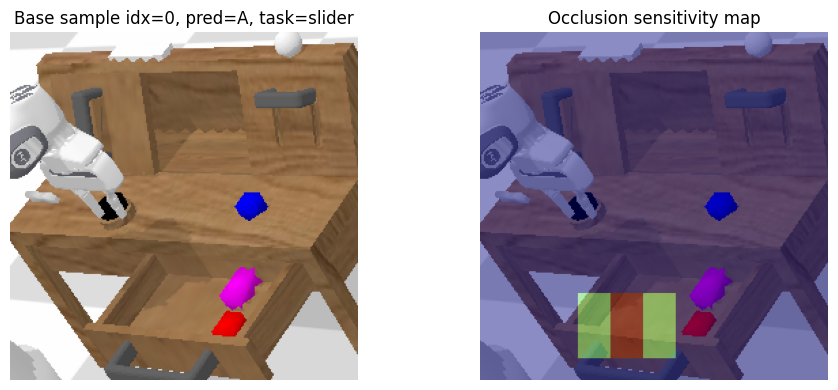

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

def predict_letter_one(image, chat_text, entity):
    one_inputs = processor(
        images=[image],
        text=[chat_text],
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    one_inputs.pop("token_type_ids", None)
    allowed_ids = cache_allowed_ids[entity]

    def one_prefix_allowed_tokens_fn(batch_id, input_ids):
        return allowed_ids

    with torch.inference_mode():
        out = model.generate(
            **one_inputs,
            max_new_tokens=1,
            do_sample=False,
            prefix_allowed_tokens_fn=one_prefix_allowed_tokens_fn,
        )

    input_len = int(one_inputs["attention_mask"].sum(dim=1).item())
    gen = out[0, input_len:]
    return processor.tokenizer.decode(gen, skip_special_tokens=True).strip().upper()


# Pick one sample to inspect
idx = 0
base_img = images[idx]
base_text = chat_texts[idx]
entity = task_names[idx]

base_pred = predict_letter_one(base_img, base_text, entity)

arr = np.array(base_img).copy()
H, W = arr.shape[:2]
patch = 48
stride = 24
heat = np.zeros((H, W), dtype=np.float32)

for y in range(0, H - patch + 1, stride):
    for x in range(0, W - patch + 1, stride):
        occluded = arr.copy()
        occluded[y : y + patch, x : x + patch] = 0
        occluded_img = Image.fromarray(occluded)

        pred = predict_letter_one(occluded_img, base_text, entity)
        changed = float(pred != base_pred)
        heat[y : y + patch, x : x + patch] += changed

heat = heat / (heat.max() + 1e-6)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(base_img)
ax[0].set_title(f"Base sample idx={idx}, pred={base_pred}, task={entity}")
ax[0].axis("off")

ax[1].imshow(base_img)
ax[1].imshow(heat, cmap="jet", alpha=0.45)
ax[1].set_title("Occlusion sensitivity map")
ax[1].axis("off")

plt.tight_layout()
plt.show()

1. logits to check if model is uncertain + it skips the generation part
2. show what momo sees: pixel_image 
3. make prompt much simpler

4. Also check what clip and tipsy see after postprocessing